# Experiment Run Analysis

Quick analysis of VLM-SAM experiment runs. **Usage:** set `INPUT_CSV_PATH` below (file or directory), run all cells, get key metrics and visualisations.

**Expected columns:** take_uid, object_name, src_camera, dest_camera, frame, experiment, vlm_model, vlm_output, vlm_reprompted, vlm_reprompt_reason, src_mask_area, vlm_growth_threshold, vlm_movement_threshold, src_move_x_ratio, src_move_y_ratio, iou, ba, ca, le, obj_rel_area, obj_dist_center, obj_size_cat, obj_is_peripheral

## 1. Configuration

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from scipy.stats import linregress, pearsonr

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

# ─── Input: path to CSV file or directory of CSVs ─────────────────────
INPUT_CSV_PATH = Path("../results/results_partial_qwen3.5_35b_num_predict_2048_bbox.csv")  # or Path("../results/results_partial_qwen3.5_35b_num_predict_1024_bbox.csv")

# Load: if directory, glob all *.csv and concat; else load single file
if INPUT_CSV_PATH.is_dir():
    csv_files = sorted(INPUT_CSV_PATH.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files in {INPUT_CSV_PATH}")
    dfs = [pd.read_csv(f) for f in csv_files]
    df = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(csv_files)} CSV(s): {[f.name for f in csv_files]}")
else:
    df = pd.read_csv(INPUT_CSV_PATH)
    print(f"Loaded: {INPUT_CSV_PATH.name}")

print(f"Rows: {len(df)}")

Loaded: results_partial_qwen3.5_35b_num_predict_2048_bbox.csv
Rows: 927


In [51]:
# Scenario inference from object_name (from baseline-overview.ipynb)
SCENARIO_KEYWORDS = {
    "basketball": ["basketball", "drills", "layup", "mikan", "jump shooting", "mid-range", "reverse layup", "hoop"],
    "bike repair": ["wheel", "tire", "flat", "tube", "chain", "lubricate", "derailleur", "derailueur", "bike", "bicycle", "pedal", "fork", "grip", "wrench", "pump"],
    "cooking": ["cooking", "making", "omelet", "scrambled", "eggs", "noodles", "pasta", "salad", "greek", "cucumber", "tomato", "sesame", "ginger", "milk tea", "chai", "coffee", "latte", "pan", "skillet", "bowl", "plate", "knife", "fork", "spoon", "board", "saucepan", "noodles", "egg", "garlic", "celery", "carrot", "pepper", "kettle", "mug", "butter", "pizza", "leek", "turmeric", "oyster", "sugar", "spaghetti", "strainer", "spatula", "scissor", "napkin", "towel", "cloth"],
    "music": ["piano", "violin", "guitar", "suzuki", "playing", "scales", "arpeggios", "freeplaying", "sheet music"],
    "health": ["first aid", "cpr", "covid", "antigen", "rapid", "test", "swab", "buffer", "extraction", "sterile", "disposable", "flowflex", "instruction manual", "water bottle"],
    "dance": ["dance", "dancing"],
    "soccer": ["soccer", "football"],
    "rock climbing": ["rock climbing", "climbing"],
}

def infer_scenario_from_object_name(obj_name: str) -> str | None:
    s = str(obj_name).lower().strip()
    s = s.rsplit("_", 1)[0] if s and s[-1].isdigit() else s
    for scenario, keywords in SCENARIO_KEYWORDS.items():
        for kw in keywords:
            if kw in s:
                return scenario
    return None

# Fallback: take_uid -> scenario from baseline
BASELINE_DIVERSITY = Path("../results/baseline_analysis/baseline_take_object_diversity.csv")
if BASELINE_DIVERSITY.exists():
    df_take_scenario = pd.read_csv(BASELINE_DIVERSITY)[["take_uid", "scenario"]].drop_duplicates()
    take_to_scenario = dict(zip(df_take_scenario["take_uid"], df_take_scenario["scenario"]))
else:
    take_to_scenario = {}

def get_scenario(row):
    s = infer_scenario_from_object_name(row["object_name"])
    if s:
        return s
    return take_to_scenario.get(row["take_uid"], "other")

df["scenario"] = df.apply(get_scenario, axis=1)
df["vlm_output_len"] = df["vlm_output"].fillna("").astype(str).str.len()

## 2. Results

### 2.1 Key Metrics

Stratified by experiment.

iou                    ba                    ca                \
              mean     std count    mean     std count    mean     std count   
experiment                                                                     
EXP-A       0.0153  0.1089   309  0.0441  0.1749   309  0.0057  0.0417   309   
EXP-B       0.0722  0.2310   309  0.1282  0.3088   309  0.0223  0.0712   309   
EXP-C       0.0824  0.2492   309  0.1439  0.3245   309  0.0257  0.0798   309   

                le                
              mean     std count  
experiment                        
EXP-A       0.9360  0.2436   309  
EXP-B       0.8454  0.3610   309  
EXP-C       0.8264  0.3779   309

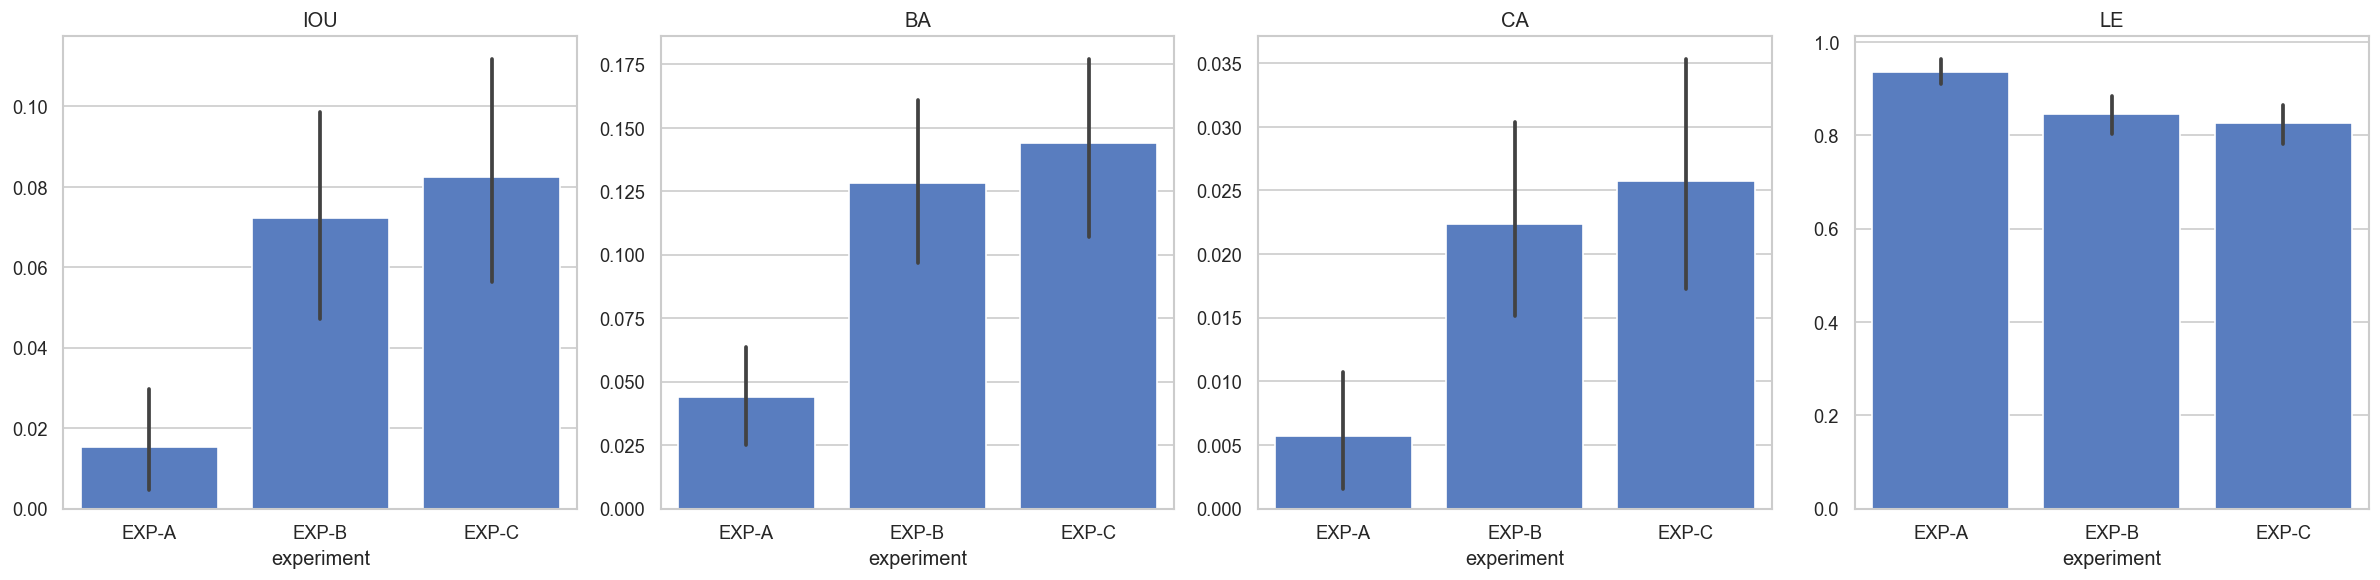

In [52]:
metrics_cols = ["iou", "ba", "ca", "le"]
avail = [c for c in metrics_cols if c in df.columns]
if not avail:
    avail = ["iou"]

by_exp = df.groupby("experiment")[avail].agg(["mean", "std", "count"]).round(4)
display(by_exp)

fig, axes = plt.subplots(1, len(avail), figsize=(5 * len(avail), 5))
if len(avail) == 1:
    axes = [axes]
for ax, col in zip(axes, avail):
    sns.barplot(data=df, x="experiment", y=col, ax=ax, order=sorted(df["experiment"].unique()))
    ax.set_title(col.upper())
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 2.2 Stratified

By scenario, object size category, peripheral, reprompt reason, and vlm_reprompted.


--- scenario (by experiment) ---


mean     std  count
experiment scenario                          
EXP-A      basketball   0.2229  0.3716      6
           bike repair  0.0070  0.0207     16
           cooking      0.0017  0.0141    184
           health       0.0793  0.2613     37
           music        0.0000  0.0000      2
           other        0.0005  0.0035     64
EXP-B      basketball   0.4052  0.4013      6
           bike repair  0.0647  0.1933     16
           cooking      0.0301  0.1475    184
           health       0.2716  0.4237     37
           music        0.1870  0.0067      2
           other        0.0449  0.1821     64
EXP-C      basketball   0.2367  0.3831      6
           bike repair  0.0108  0.0332     16
           cooking      0.0521  0.1969    184
           health       0.3561  0.4547     37
           music        0.0000  0.0000      2
           other        0.0175  0.0792     64

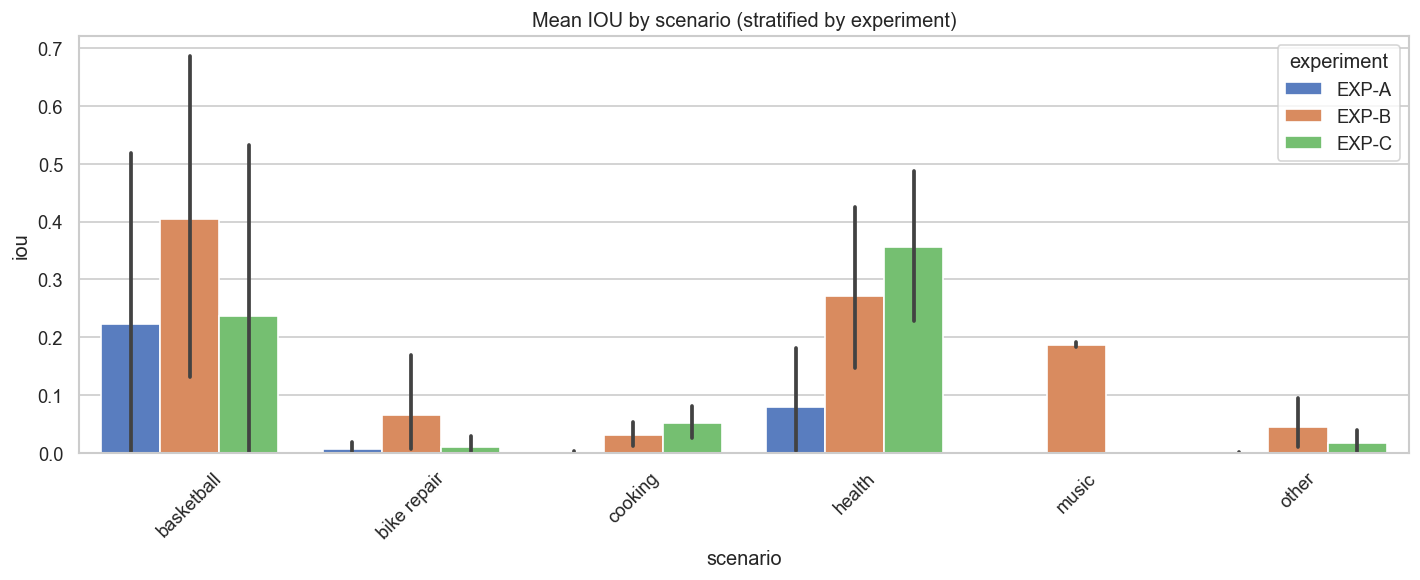


--- obj_size_cat (by experiment) ---


mean     std  count
experiment obj_size_cat                       
EXP-A      large         0.0000  0.0000      6
           medium        0.0214  0.1259     59
           small         0.0142  0.1060    244
EXP-B      large         0.0000  0.0000      6
           medium        0.0949  0.2848     59
           small         0.0685  0.2191    244
EXP-C      large         0.0000  0.0000      6
           medium        0.1682  0.3572     59
           small         0.0637  0.2144    244

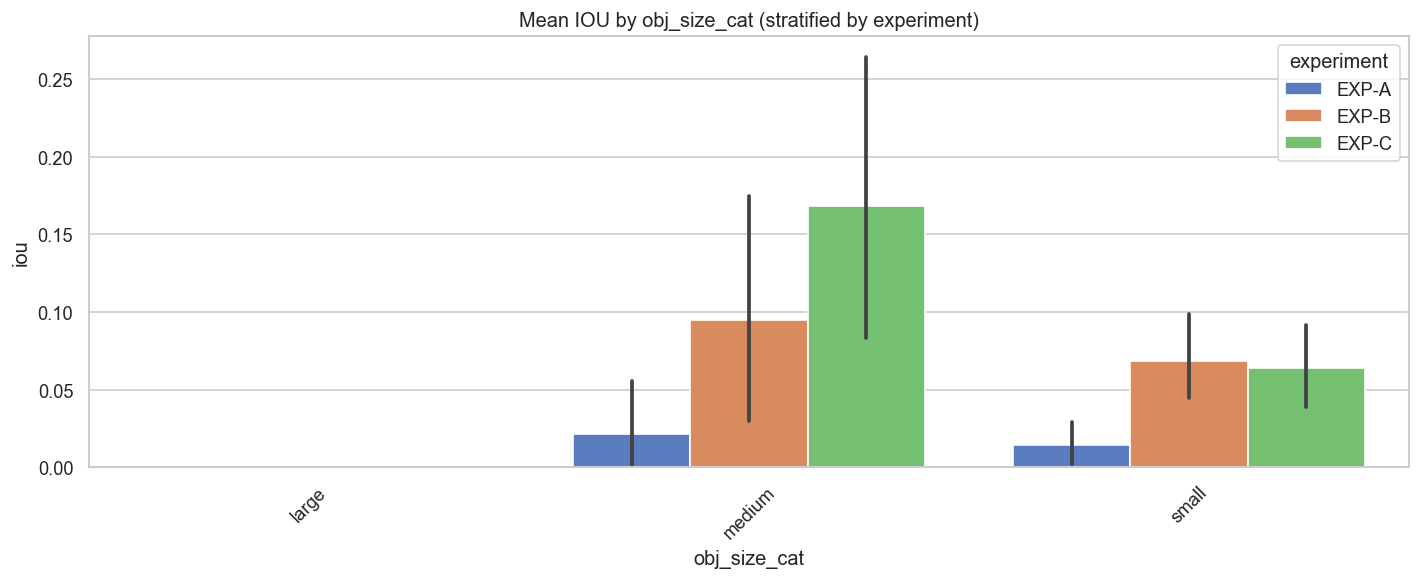


--- obj_is_peripheral (by experiment) ---


mean     std  count
experiment obj_is_peripheral                       
EXP-A      False              0.0165  0.1133    285
           True               0.0004  0.0019     24
EXP-B      False              0.0773  0.2397    285
           True               0.0117  0.0310     24
EXP-C      False              0.0836  0.2523    285
           True               0.0688  0.2135     24

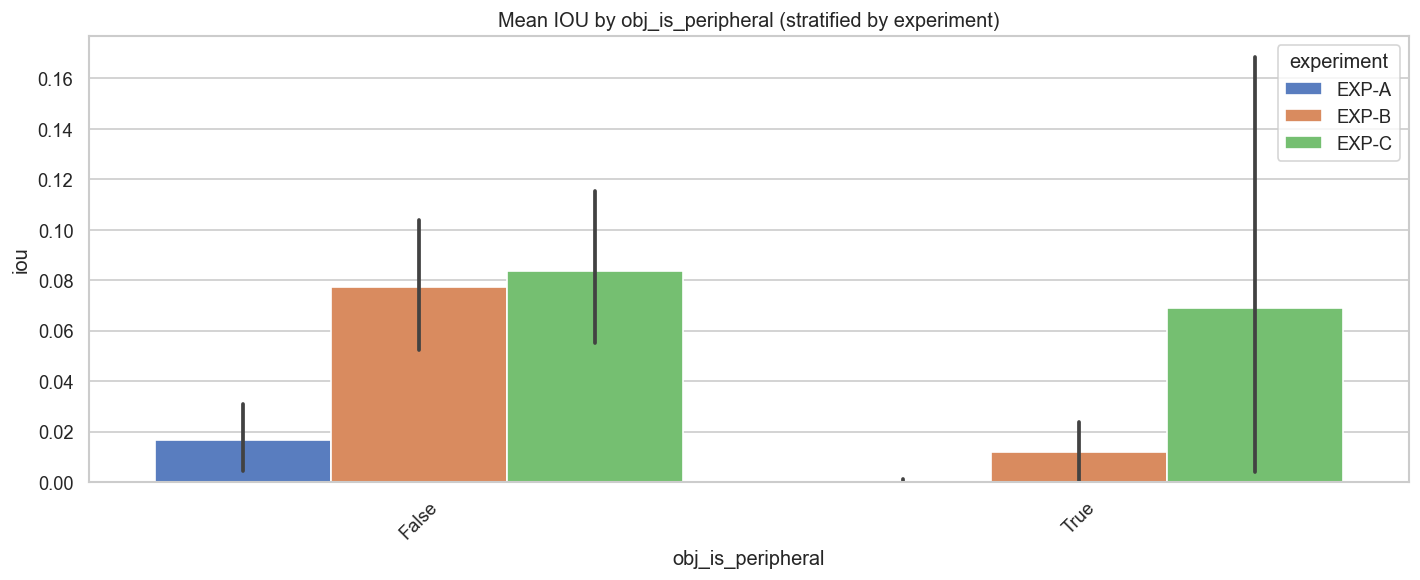


--- vlm_reprompt_reason (by experiment) ---


mean     std  count
experiment vlm_reprompt_reason                       
EXP-A      cold_start           0.0275  0.1475    127
           growth               0.0002  0.0008     18
           growth+movement      0.0000  0.0000     21
           movement             0.0025  0.0167     67
           reuse                0.0139  0.1068     76
EXP-B      cold_start           0.1064  0.2769    127
           growth               0.0383  0.1623     18
           growth+movement      0.0472  0.1957     21
           movement             0.0009  0.0053     67
           reuse                0.0929  0.2582     76
EXP-C      cold_start           0.1323  0.3095    127
           growth               0.0586  0.2254     18
           growth+movement      0.0045  0.0207     21
           movement             0.0062  0.0447     67
           reuse                0.0935  0.2634     76

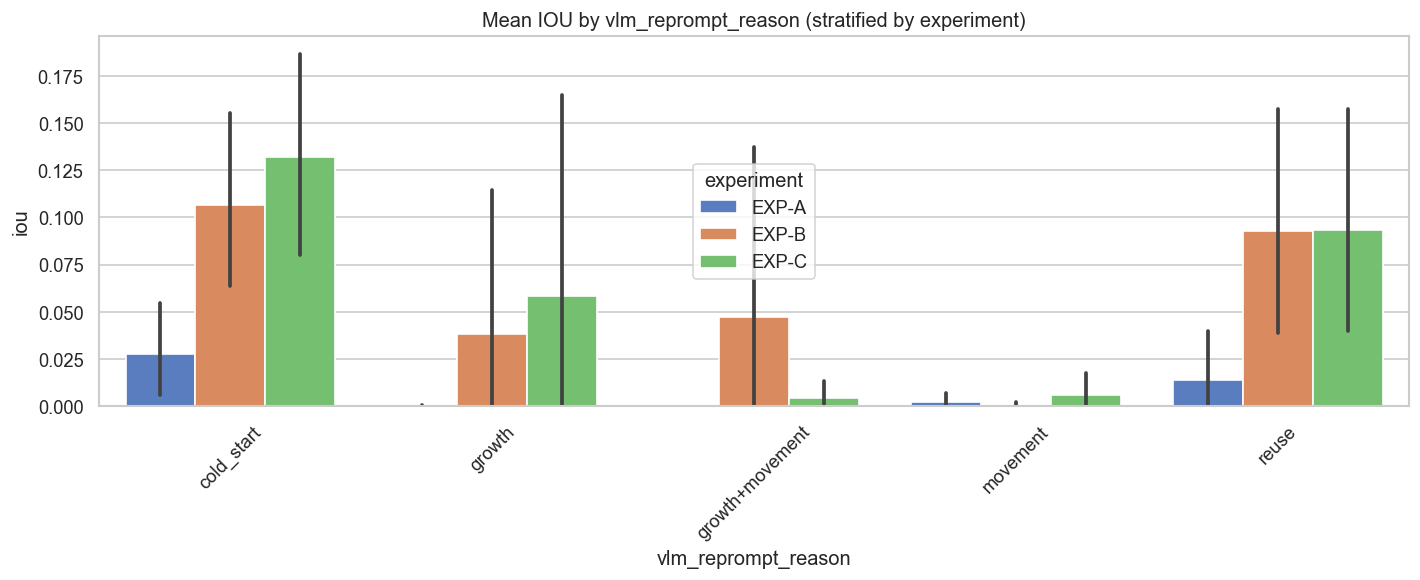


--- vlm_reprompted (by experiment) ---


mean     std  count
experiment vlm_reprompted                       
EXP-A      False           0.0139  0.1068     76
           True            0.0157  0.1098    233
EXP-B      False           0.0929  0.2582     76
           True            0.0654  0.2216    233
EXP-C      False           0.0935  0.2634     76
           True            0.0788  0.2449    233

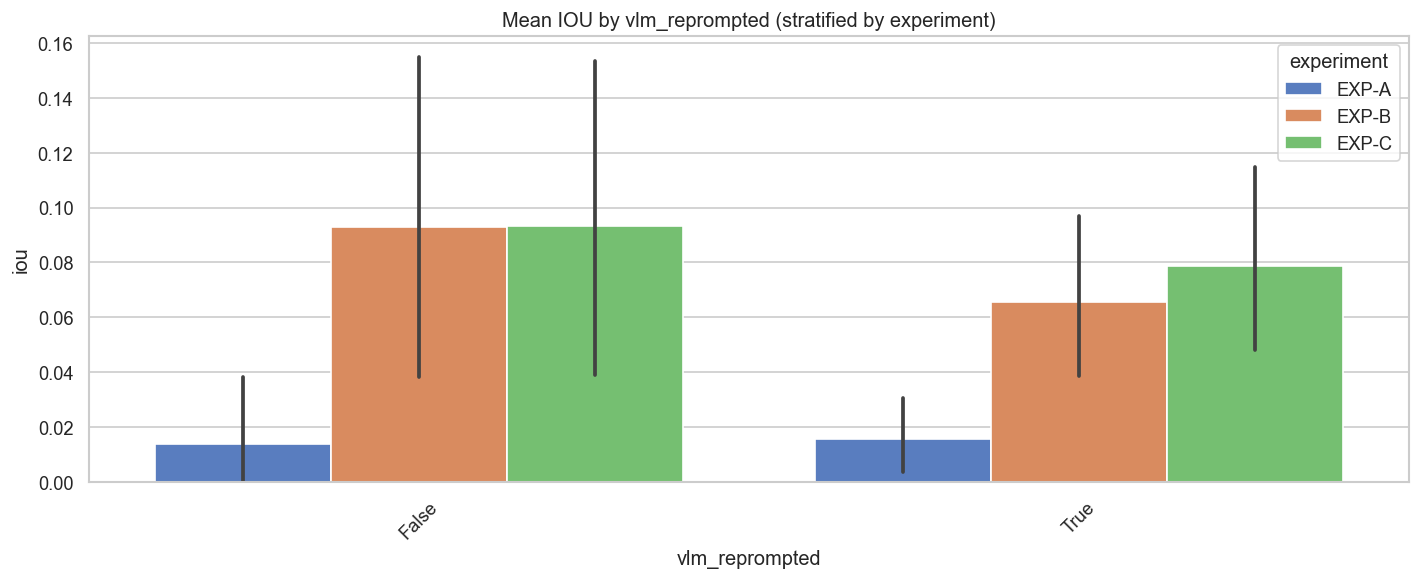

In [ ]:
strat_cols = ["scenario", "obj_size_cat", "obj_is_peripheral", "vlm_reprompt_reason", "vlm_reprompted"]
strat_cols = [c for c in strat_cols if c in df.columns]

for col in strat_cols:
    by_strat = df.groupby(["experiment", col])["iou"].agg(["mean", "std", "count"]).round(4)
    print(f"\n--- {col} (by experiment) ---")
    display(by_strat)
    fig, ax = plt.subplots(figsize=(12, 5))
    order = sorted(df[col].astype(str).unique(), key=lambda x: (x == "other", x))
    sns.barplot(data=df, x=col, y="iou", hue="experiment", ax=ax, order=order)
    ax.set_title(f"Mean IOU by {col} (stratified by experiment)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="experiment")
    plt.tight_layout()
    plt.show()

### 2.3 Other

GT area vs IOU, object relative area vs IOU, object size by GT area and IOU, IOU vs distance from center, IOU vs movement ratios, IOU vs VLM output length.

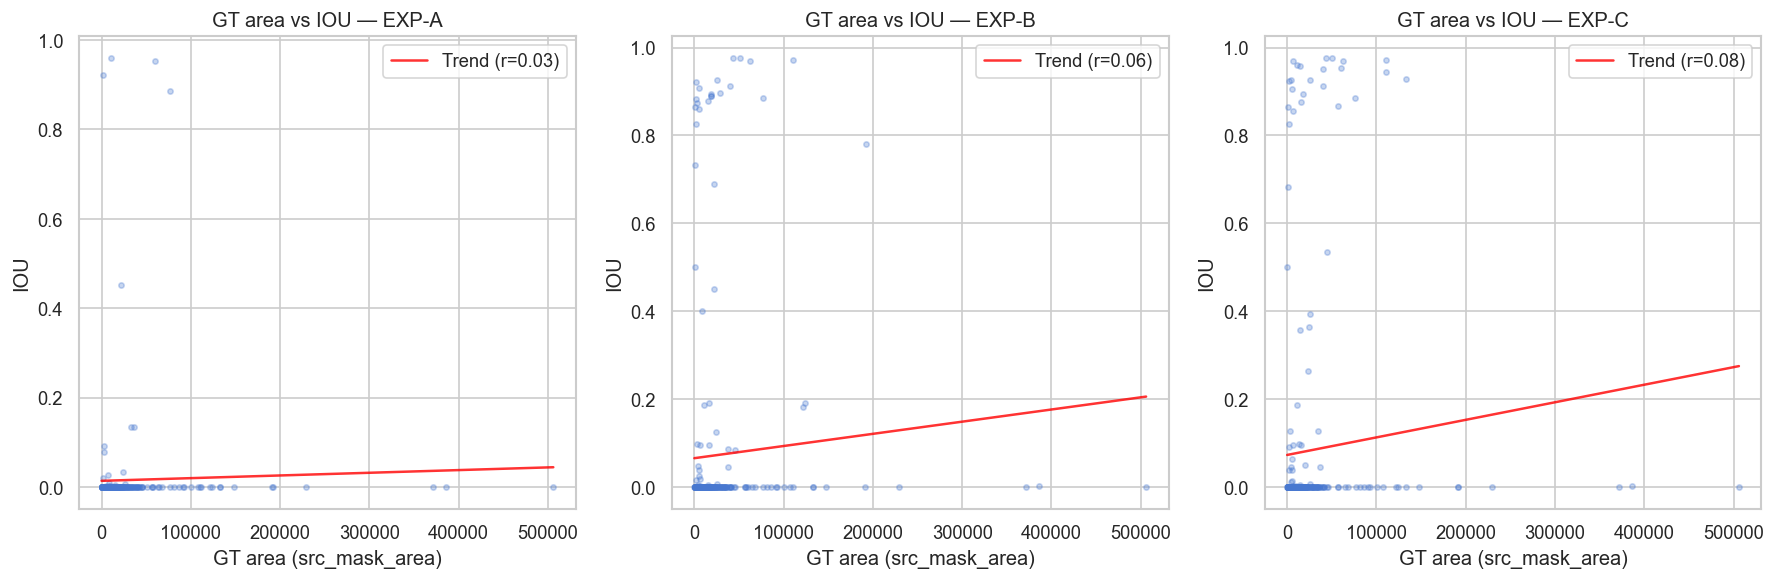

In [54]:
# GT area vs IOU (one subplot per experiment)
experiments = sorted(df["experiment"].unique())
n_exp = len(experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 5))
if n_exp == 1:
    axes = [axes]
for ax, exp in zip(axes, experiments):
    d = df[df["experiment"] == exp]
    x, y = d["src_mask_area"], d["iou"]
    ax.scatter(x, y, alpha=0.3, s=10)
    not_na = x.notna() & y.notna()
    if not_na.any():
        slope, intercept, r_value, p_value, std_err = linregress(x[not_na], y[not_na])
        x_fit = np.linspace(x[not_na].min(), x[not_na].max(), 100)
        ax.plot(x_fit, slope * x_fit + intercept, color='red', alpha=0.8, label=f"Trend (r={r_value:.2f})")
        ax.legend()
    ax.set_xlabel("GT area (src_mask_area)")
    ax.set_ylabel("IOU")
    ax.set_title(f"GT area vs IOU — {exp}")
plt.tight_layout()
plt.show()

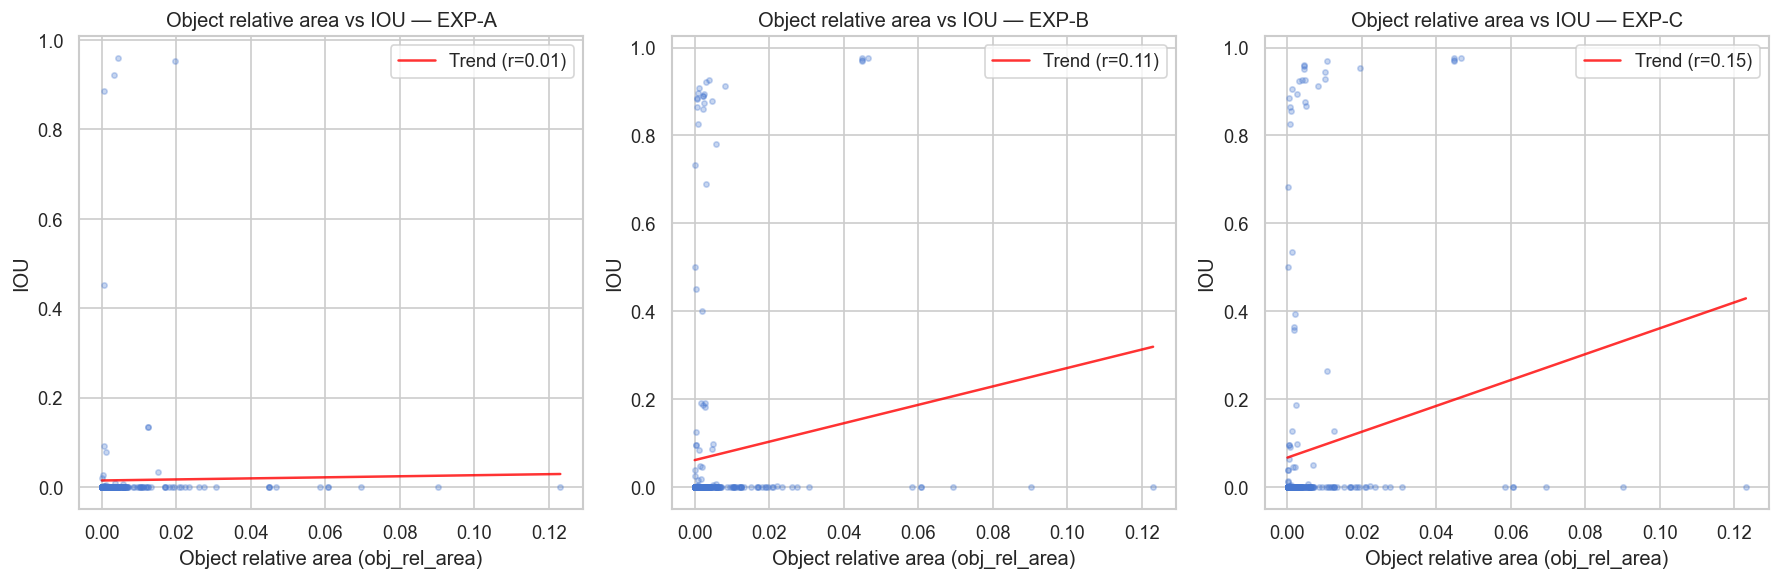

In [55]:
# Object relative area vs IOU (one subplot per experiment)
if "obj_rel_area" in df.columns:
    experiments = sorted(df["experiment"].unique())
    n_exp = len(experiments)
    fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 5))
    if n_exp == 1:
        axes = [axes]
    for ax, exp in zip(axes, experiments):
        d = df[df["experiment"] == exp]
        x, y = d["obj_rel_area"], d["iou"]
        ax.scatter(x, y, alpha=0.3, s=10)
        not_na = x.notna() & y.notna()
        if not_na.any():
            slope, intercept, r_value, p_value, std_err = linregress(x[not_na], y[not_na])
            x_fit = np.linspace(x[not_na].min(), x[not_na].max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, color='red', alpha=0.8, label=f"Trend (r={r_value:.2f})")
            ax.legend()
        ax.set_xlabel("Object relative area (obj_rel_area)")
        ax.set_ylabel("IOU")
        ax.set_title(f"Object relative area vs IOU — {exp}")
    plt.tight_layout()
    plt.show()

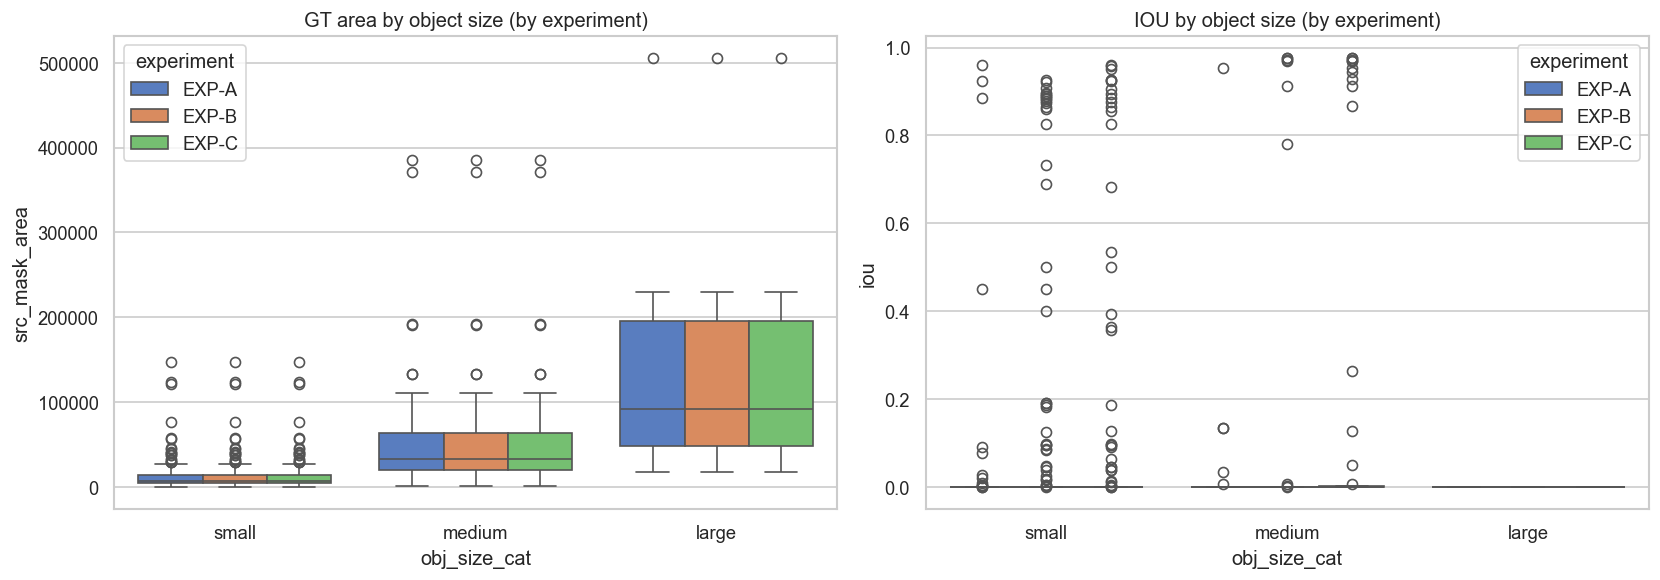

In [56]:
# Object size classes: GT area and IOU stratified by obj_size_cat and experiment
if "obj_size_cat" in df.columns and "src_mask_area" in df.columns:
    size_order = [c for c in ["small", "medium", "large"] if c in df["obj_size_cat"].unique()]
    size_order = size_order or sorted(df["obj_size_cat"].unique())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=df, x="obj_size_cat", y="src_mask_area", hue="experiment", ax=axes[0], order=size_order)
    axes[0].set_title("GT area by object size (by experiment)")
    axes[0].set_ylabel("src_mask_area")
    sns.boxplot(data=df, x="obj_size_cat", y="iou", hue="experiment", ax=axes[1], order=size_order)
    axes[1].set_title("IOU by object size (by experiment)")
    plt.tight_layout()
    plt.show()

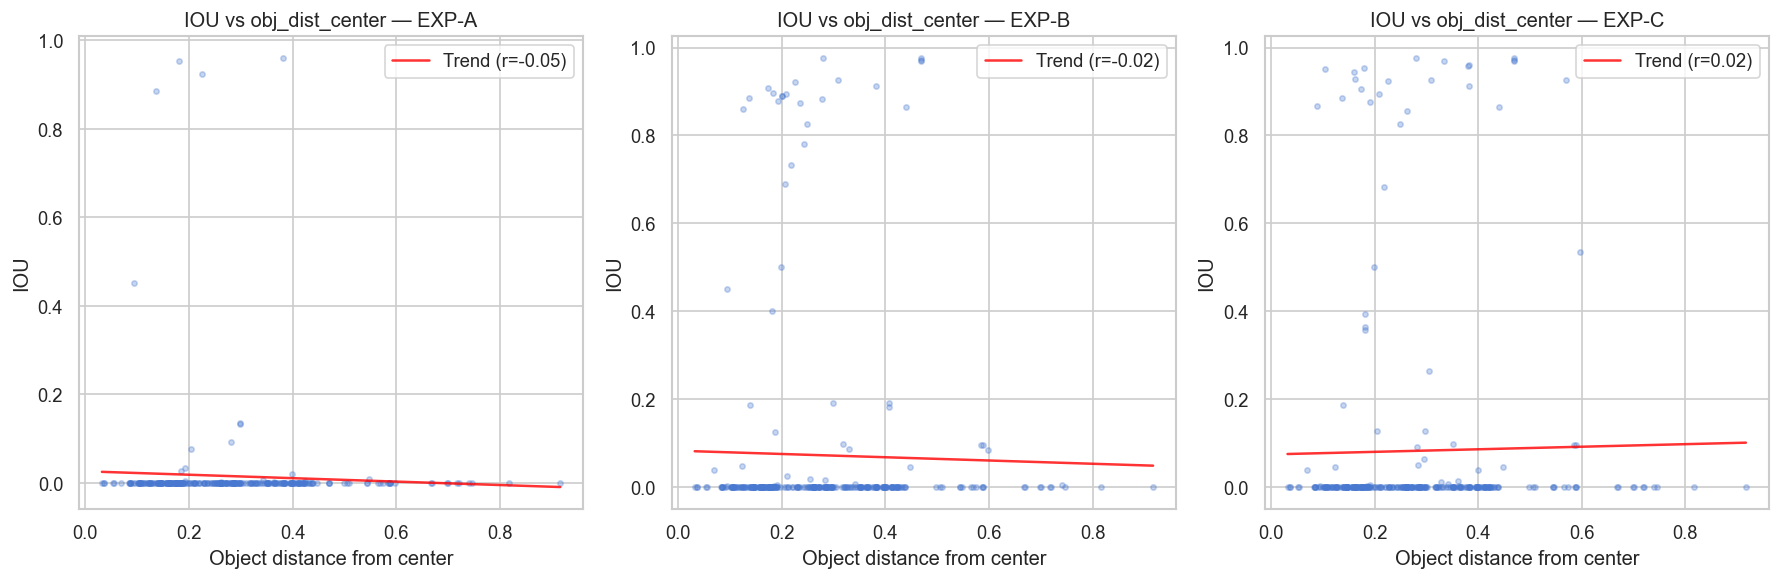

In [57]:
# IOU vs obj_dist_center (one subplot per experiment)
if "obj_dist_center" in df.columns:
    experiments = sorted(df["experiment"].unique())
    n_exp = len(experiments)
    fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 5))
    if n_exp == 1:
        axes = [axes]
    for ax, exp in zip(axes, experiments):
        d = df[df["experiment"] == exp]
        x, y = d["obj_dist_center"], d["iou"]
        ax.scatter(x, y, alpha=0.3, s=10)
        not_na = x.notna() & y.notna()
        if not_na.any():
            slope, intercept, r_value, p_value, std_err = linregress(x[not_na], y[not_na])
            x_fit = np.linspace(x[not_na].min(), x[not_na].max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, color='red', alpha=0.8, label=f"Trend (r={r_value:.2f})")
            ax.legend()
        ax.set_xlabel("Object distance from center")
        ax.set_ylabel("IOU")
        ax.set_title(f"IOU vs obj_dist_center — {exp}")
    plt.tight_layout()
    plt.show()

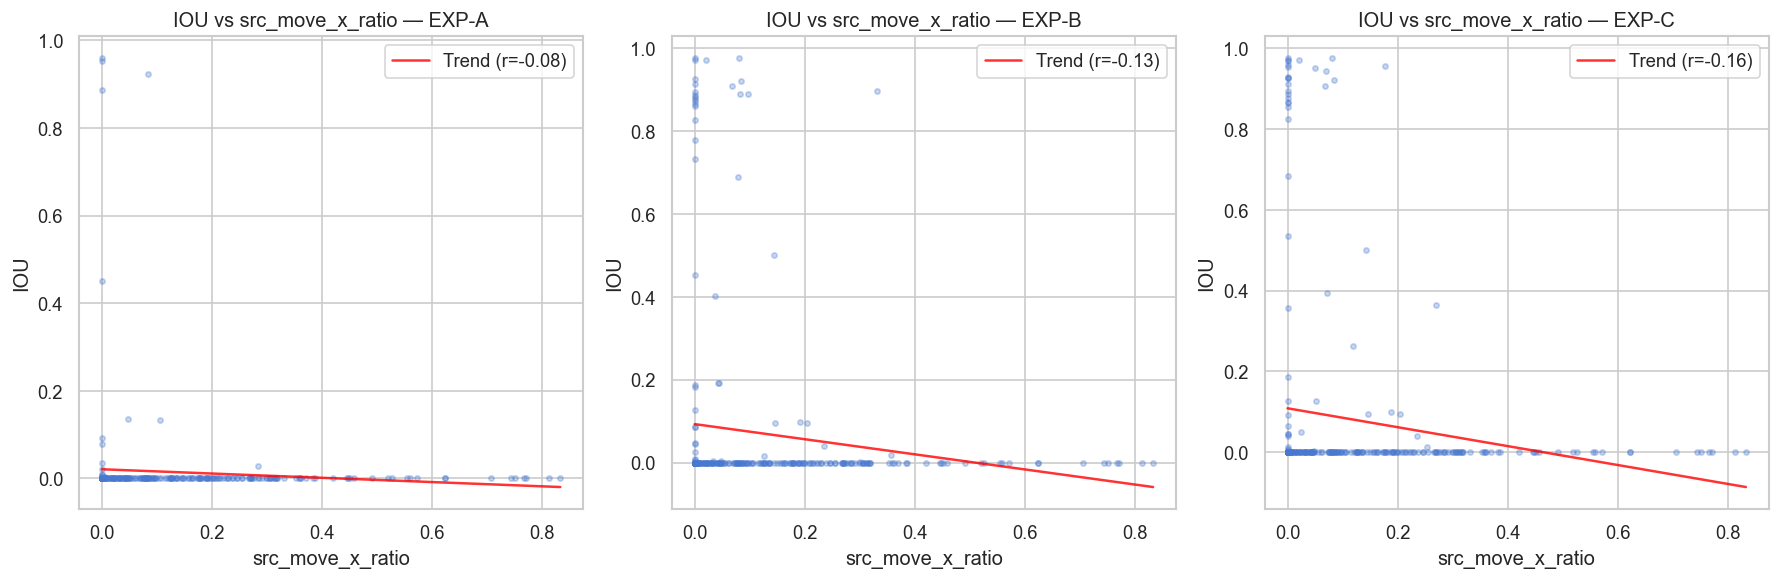

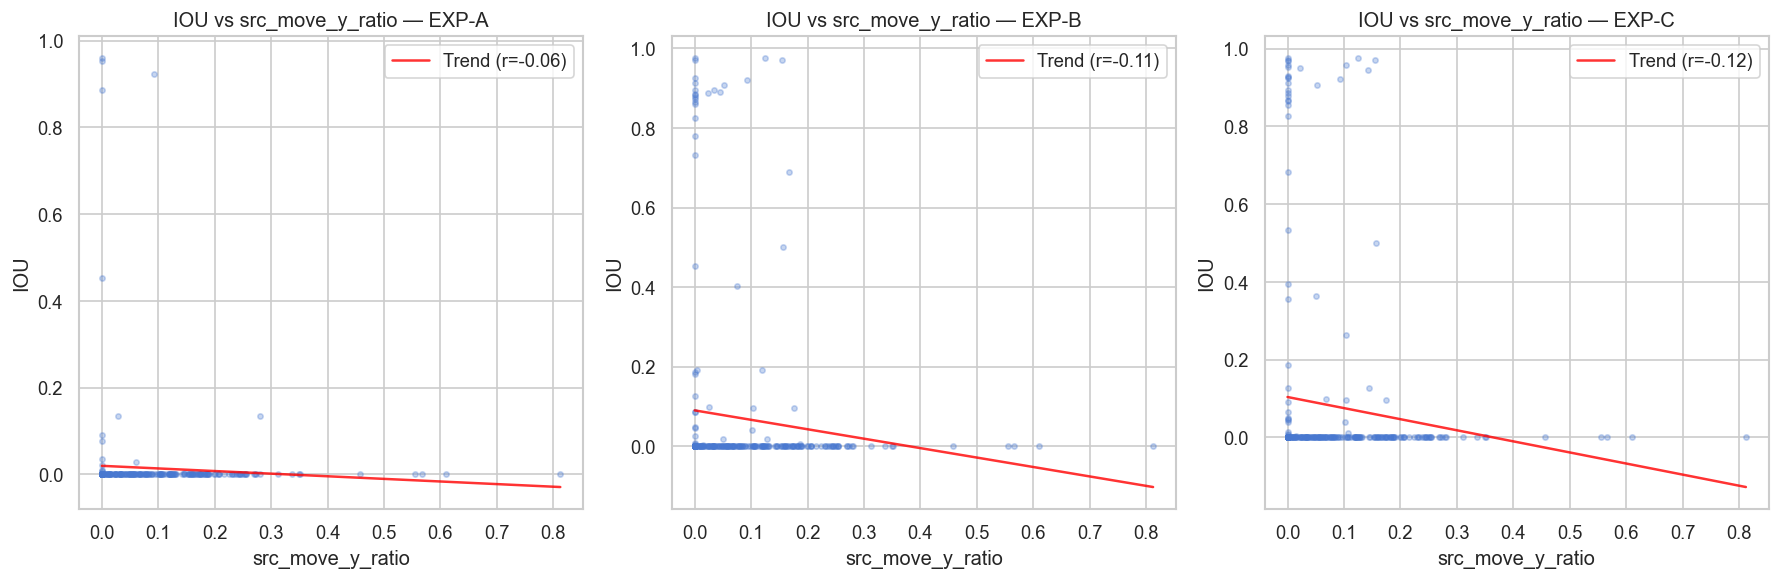

In [58]:
# IOU vs src_move_x_ratio and src_move_y_ratio (one subplot per experiment, per move col)
move_cols = ["src_move_x_ratio", "src_move_y_ratio"]
move_cols = [c for c in move_cols if c in df.columns]
if move_cols:
    experiments = sorted(df["experiment"].unique())
    n_exp = len(experiments)
    for col in move_cols:
        fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 5))
        if n_exp == 1:
            axes = [axes]
        for ax, exp in zip(axes, experiments):
            d = df[df["experiment"] == exp]
            x, y = d[col], d["iou"]
            ax.scatter(x, y, alpha=0.3, s=10)
            not_na = x.notna() & y.notna()
            if not_na.any():
                slope, intercept, r_value, p_value, std_err = linregress(x[not_na], y[not_na])
                x_fit = np.linspace(x[not_na].min(), x[not_na].max(), 100)
                ax.plot(x_fit, slope * x_fit + intercept, color='red', alpha=0.8, label=f"Trend (r={r_value:.2f})")
                ax.legend()
            ax.set_xlabel(col)
            ax.set_ylabel("IOU")
            ax.set_title(f"IOU vs {col} — {exp}")
        plt.tight_layout()
        plt.show()

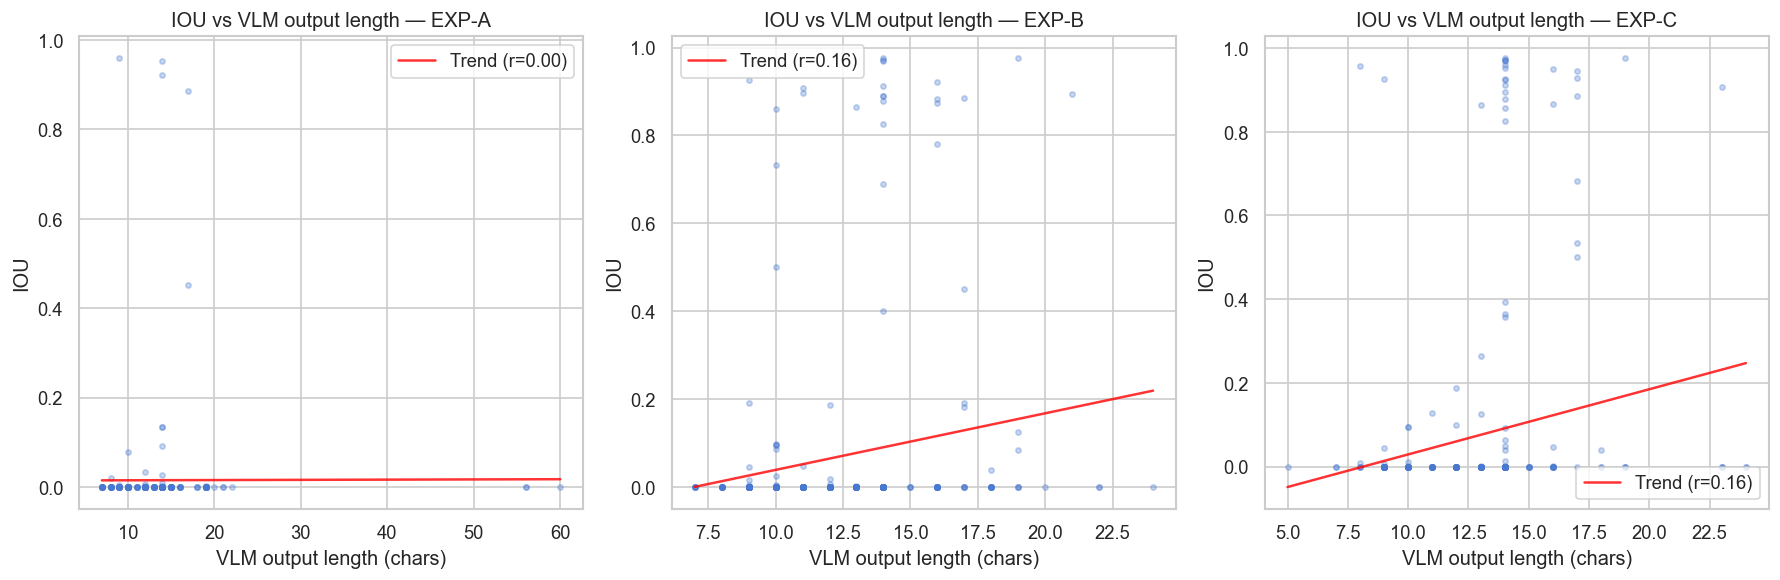

In [59]:
# IOU vs length of VLM output (one subplot per experiment)
experiments = sorted(df["experiment"].unique())
n_exp = len(experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 5))
if n_exp == 1:
    axes = [axes]
for ax, exp in zip(axes, experiments):
    d = df[df["experiment"] == exp]
    x, y = d["vlm_output_len"], d["iou"]
    ax.scatter(x, y, alpha=0.3, s=10)
    not_na = x.notna() & y.notna()
    if not_na.any():
        slope, intercept, r_value, p_value, std_err = linregress(x[not_na], y[not_na])
        x_fit = np.linspace(x[not_na].min(), x[not_na].max(), 100)
        ax.plot(x_fit, slope * x_fit + intercept, color='red', alpha=0.8, label=f"Trend (r={r_value:.2f})")
        ax.legend()
    ax.set_xlabel("VLM output length (chars)")
    ax.set_ylabel("IOU")
    ax.set_title(f"IOU vs VLM output length — {exp}")
plt.tight_layout()
plt.show()

### 2.4 VLM Prompt Analysis

NLP analysis of VLM outputs across all rows, stratified by experiment.

Experiment: EXP-A     Mean: 13.64  Median: 14.00  Mode: 14
Experiment: EXP-B     Mean: 12.58  Median: 13.00  Mode: 14
Experiment: EXP-C     Mean: 13.42  Median: 14.00  Mode: 14


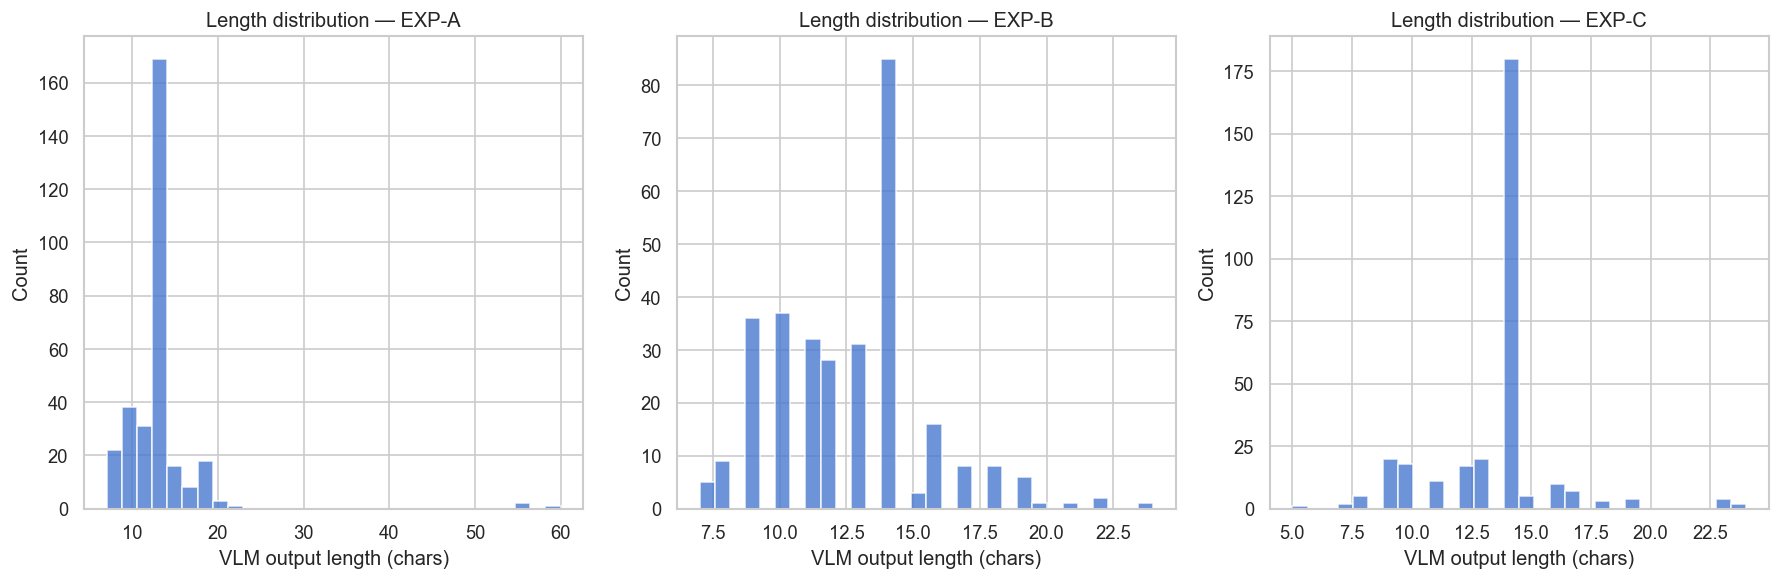

In [60]:
# Length distribution (stratified by experiment) + print mean/median/mode
if "vlm_output_len" in df.columns:
    from scipy import stats
    experiments = sorted(df["experiment"].unique())
    n_exp = len(experiments)
    fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 5))
    if n_exp == 1:
        axes = [axes]
    for ax, exp in zip(axes, experiments):
        d = df[df["experiment"] == exp]
        lens = d["vlm_output_len"].dropna()
        # Compute statistics
        mean_val = lens.mean()
        median_val = lens.median()
        if len(lens) > 0:
            mode_val = stats.mode(lens, keepdims=True)[0][0]
        else:
            mode_val = float("nan")
        print(f"Experiment: {exp:8s}  Mean: {mean_val:.2f}  Median: {median_val:.2f}  Mode: {mode_val}")
        ax.hist(lens, bins=30, edgecolor="white", alpha=0.8)
        ax.set_xlabel("VLM output length (chars)")
        ax.set_ylabel("Count")
        ax.set_title(f"Length distribution — {exp}")
    plt.tight_layout()
    plt.show()

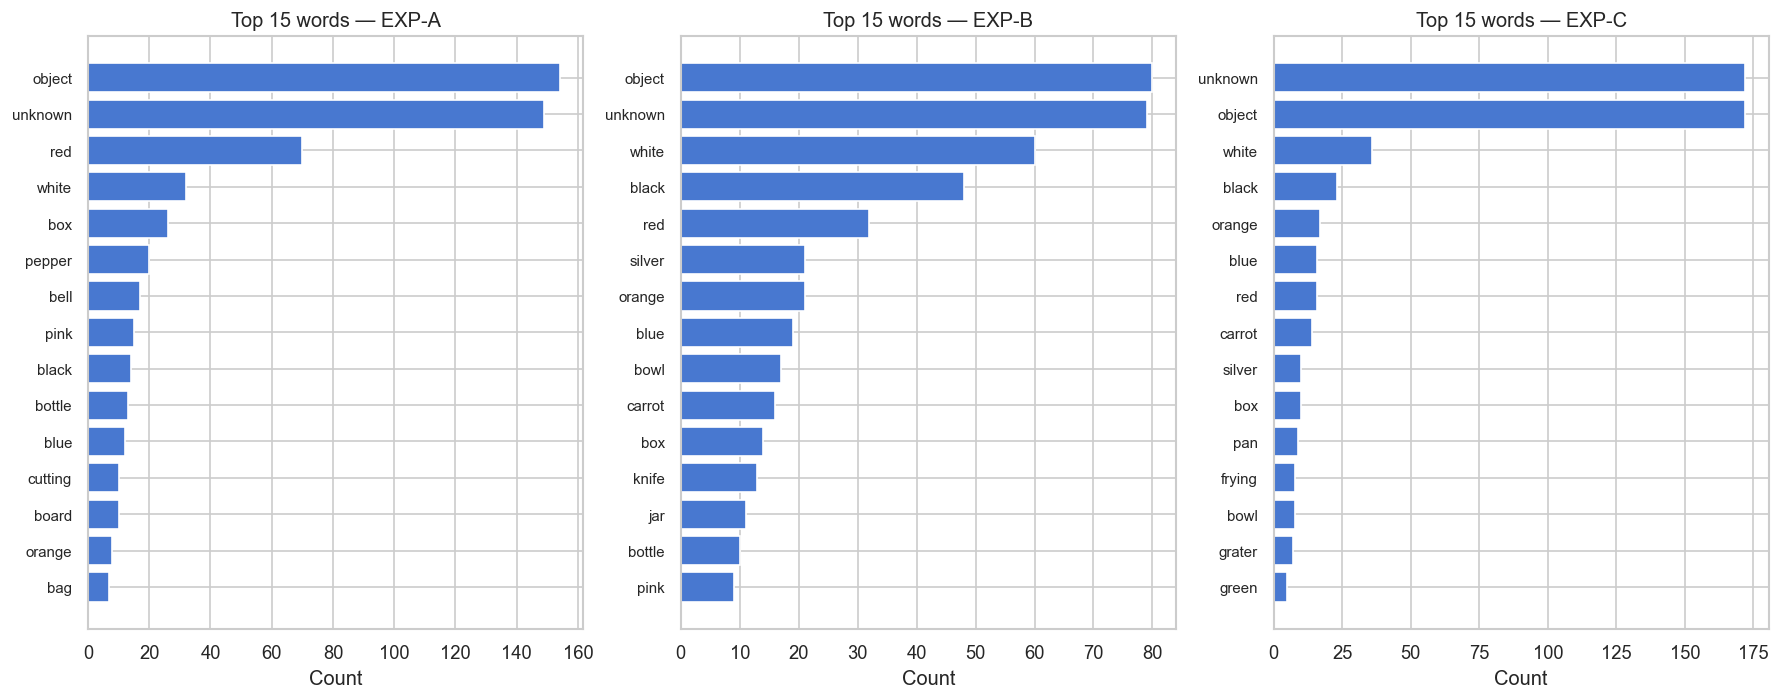

In [61]:
# Most common words (stratified by experiment)
import re
from collections import Counter

if "vlm_output" in df.columns:
    def tokenize(text):
        return re.findall(r"\b[a-z]{2,}\b", str(text).lower())

    top_n = 15
    experiments = sorted(df["experiment"].unique())
    n_exp = len(experiments)
    fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 6))
    if n_exp == 1:
        axes = [axes]
    for ax, exp in zip(axes, experiments):
        d = df[df["experiment"] == exp]
        all_words = []
        for t in d["vlm_output"].fillna(""):
            all_words.extend(tokenize(t))
        counts = Counter(all_words).most_common(top_n)
        if counts:
            words, freqs = zip(*counts)
            ax.barh(range(len(words)), freqs, align="center")
            ax.set_yticks(range(len(words)))
            ax.set_yticklabels(words, fontsize=9)
            ax.invert_yaxis()
        ax.set_xlabel("Count")
        ax.set_title(f"Top {top_n} words — {exp}")
    plt.tight_layout()
    plt.show()